In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/HW2"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# Homework 2: Randomized Block and Latin Square Designs
### Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
  * The objective of this experiment is to determine which teaching method will produce the best understanding of hypothesis testing basics.

**Question 2.** Specify the outcome variable
  * Outcome variable: Score ( quantitative, continuous variable)

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?
  * The teaching method is the IV, that is categorical. The blocking factor is prior knowledge. A possoible lurking factor would be if the participants received ourside knowledge while in the program. That could skew the scores on the quiz they take at the end.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.
  * A randomized block design would be appropriate here because we are not starting from scratch. We have something we want to test but there is source of variation we have to look out for, which is participants coming in with prior knowledge on the subject.

**Question 5.** State the null and alternative hypotheses for this experiment.
$$ H_0: \mu_1 = \mu_2 = \dots = \mu_t $$

$$ H_1: \text{At least one pair of group means are not equal} $$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114


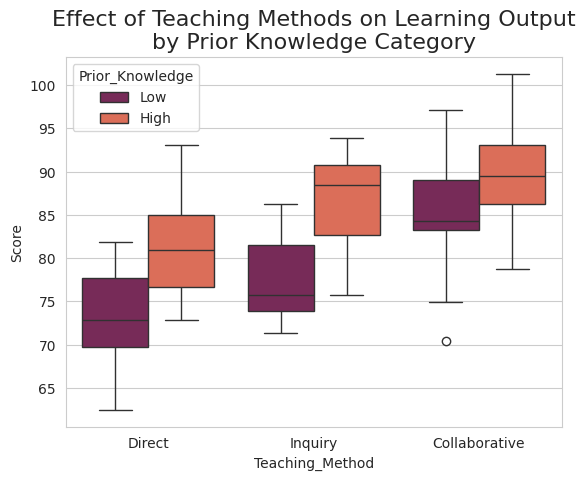

In [14]:
## Import Necessary Python Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

##Import the Data Science Teaching Method Data ##

dstm_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Data Science Teaching Method.xlsx")

## Data Integrity Check with .info ##

print(dstm_data.info())

## Calculate Mean and Standard Deviation
## Calculate Means and Standard Deviations
## by BMI Group and Treatment Group ##

dstm_sum_stats = dstm_data.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean','std'])

print(dstm_sum_stats)


## Step 2: Create the boxplot using seaborn.
## We use the `order` and `hue_order` parameters to ensure the correct order.

sns.set_style("whitegrid")

sns.boxplot(
    data=dstm_data,
    x='Teaching_Method',
    y='Score',
    hue='Prior_Knowledge',
    palette='rocket' # Choose a color palette
)

## Step 3: Add labels and titles ##

plt.title("Effect of Teaching Methods on Learning Output\nby Prior Knowledge Category",
          loc='center',
          fontsize=16)

## Show the plot ##

plt.show()

  * The summary statistics and  boxplots display
a difference in the mean number of test scores between each teaching method group. Participants within the high prior knowledge group produce a high mean score throughout all teaching methods. Direct teaching seems to have a lower mean of test scores than inquiry and collaborative teaching. The evidence supports the alternative hypothesis.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

In [4]:
## Fit ANOVA Model ##

teaching_mod = ols("Score~Teaching_Method+Prior_Knowledge",data=dstm_data).fit()

## Obtain ANOVA Table ##

teaching_tab = sm.stats.anova_lm(teaching_mod,typ=2)

## Add Significance Column ##

teaching_tab["Significance"] = np.where(teaching_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Print Only Treatment & BMI Rows ##

print(teaching_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


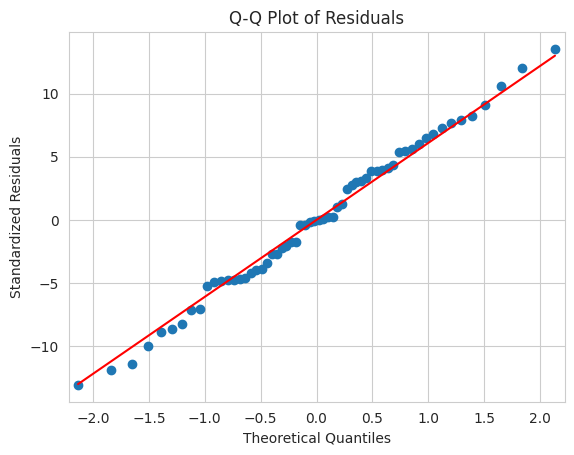

Shapiro-Wilk Test Statistic: 0.989
Shapiro-Wilk P-value: 0.879

Based on the Shapiro-Wilk test (p > 0.05), we fail to reject the null hypothesis of normality. The residuals appear to be normally distributed.


In [5]:
## Question 7: Test the assumption of normality ##

# Get the residuals from the ANOVA model
residuals = teaching_mod.resid

# Visual Method: Q-Q plot
fig = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

# Testing Method: Shapiro-Wilk Test
from scipy.stats import shapiro
shapiro_test = shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.3f}")
print(f"Shapiro-Wilk P-value: {shapiro_test.pvalue:.3f}")

# Interpret the results
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("\nBased on the Shapiro-Wilk test (p > 0.05), we fail to reject the null hypothesis of normality. The residuals appear to be normally distributed.")
else:
    print("\nBased on the Shapiro-Wilk test (p <= 0.05), we reject the null hypothesis of normality. The residuals do not appear to be normally distributed.")

  * The QQ-plot shows most of the
points fall very closely to the diagonal line. This provides strong evidence in favor of the
normality assumption being met. The Shapiro-Wilk test result, we can see
that we have a p-value of 0.879 which would indicate that the data does not deviate from normality. In sum, normality feels reasonably supported by the sample data.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?


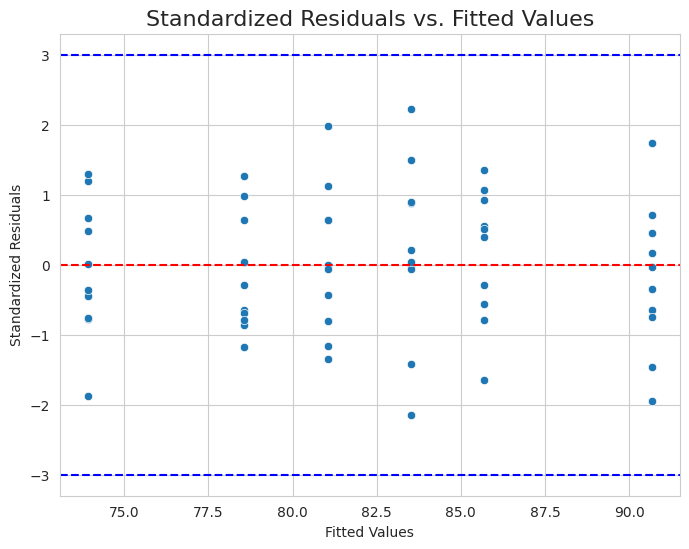

F-statistic: 0.7579465871345045
F p-value: 0.5224437459616452
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [7]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = teaching_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = teaching_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(teaching_mod.resid,teaching_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

  * As we look at residual scatterplot, there are no possible outliers above or below 3. The p-value associated with the B-P test statistic, 0.5224, indicates that the data support the null hypothesis of constant variance.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



In [9]:
## Print ANOVA Table Again ##

print(teaching_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


  * The F-statistic, 11.632, and its associated p-value of 0.00006 which is less than 0.001, is evidence that our data more strongly supports the alternative hypothesis for the test of the main effect.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


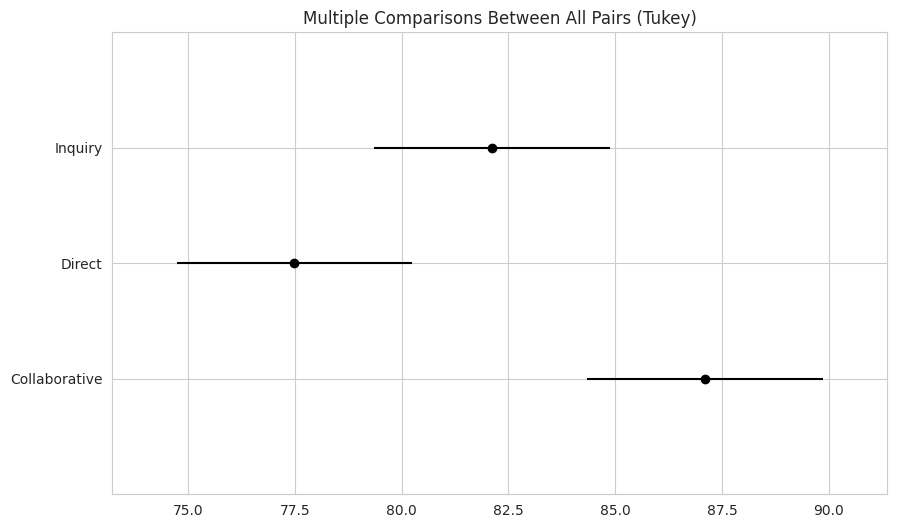

In [10]:
## Import pairwise_tukeyhsd function ##

from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test (Remember, we renamed Exercise Treatment to Exercise_Treatment) ##

tukey_result = pairwise_tukeyhsd(endog=dstm_data['Score'], groups=dstm_data['Teaching_Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(tukey_result.plot_simultaneous())

print(tukey_result)

  * The Tukey report shows comparing the collaborative and direct group, the p-value is less than 0.05. The p-value of the collaborative and direct teaching method groups indicates that score group means may differ substantially from each other, controlling for prior knowledge category.
  * Comparing the teaching methods collaborative and inquiry, the p-value is 0.0838. The p-value when comparing inquiry and direct teaching methods is 0.1168. These p-values comparing the remaining pairs are greater than 0.05, indicating there is not a statistically significant different between the groups.
  * The results of Tukey does support the alternative hypothesis that there is a statistical difference between the group means.

  
**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.
  * Overall, we performed an experiment comparing the mean quiz scores that was given at the end of workshops that were taught using three different methods. Given that participant could had prior knowledge on the subject, we controlled for that by categorizing them as high or low priod knowledge. The three teaching methods of the workshops were direct, inquiry and collaborative. Descriptive analyses supported the hypothesis that meaningful differences would exist and this
was further supported by the validated omnibus F-test.  The post-hoc analysis determined that
all group means besides direct and collaborative teaching did not differ statistically. The collaborative teaching method group had the greatest group mean, followed by inquiry and then direct. A potential limitation would be knowing whether or not the participants learned the material from outside sources during the workshops. Outside sources, beyond the prior knowledge accounted for, could skew the quiz results so going forward that could be investigated.

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
  * The objective of this experiment is to compare the mean engagement across the four learning platforms, controlling for day of the week and time of the day.

**Question 2.** Specify the outcome variable
  * Engagement, which is a quantitative, continuous variable.

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?
  * Independent variable: Platform
  * Blocking factor: (1) Day of week (2) Time of day
  * Possible lurking variables: Varying reasons to log in, could increase engagement

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.
  * A latin square design would be appropriate due to time of day and day of the week being our two blocking factors. A latin square design requires the number of levels of the treatment and blocking factor to be equal.  A random block design works better when it is one blocking factor. A completely randomized design is more appropriate for experiments without a blocking factor, solely focusing on the difference in treatment effect.

**Question 5.** State the null and alternative hypotheses for this experiment.
$$ H_0: \mu_1 = \mu_2 = \dots = \mu_t $$

$$ H_1: \text{At least two group means differ} $$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

In [11]:
## Import Necessary Packages ##
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Read in Latin Square Dog Toys Data ##

ole_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Online Learning and Engagement.xlsx")


## Data Integrity Check ##

print(ole_data.info())

## Calcualte Means and Standard Deviations ##

sum_stats = ole_data.groupby("Platform")["Engagement"].agg(['mean','std'])

print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Day         16 non-null     object 
 1   Section     16 non-null     object 
 2   Platform    16 non-null     object 
 3   Engagement  16 non-null     float64
dtypes: float64(1), object(3)
memory usage: 644.0+ bytes
None
               mean        std
Platform                      
A         1408.8475  19.319733
B         1339.7200  39.845434
C         1332.6425  32.288451
D         1379.0225   7.354601


/tmp/ipython-input-2076596398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


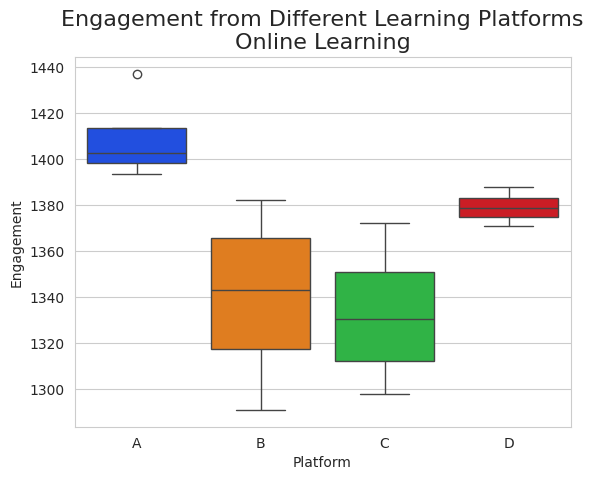

In [12]:
## Build a Boxplot ##

## Set up style ##

sns.set_style("whitegrid")

## Specify Aesthetics ##

sns.boxplot(
    data=ole_data,
    x='Platform',
    y='Engagement',
    palette='bright'
)

## Add labels and titles ##

plt.title("Engagement from Different Learning Platforms\nOnline Learning",
          loc='center',
          fontsize=16)

## Show the plot ##

plt.show()

* The summary statistics and  boxplots display
a difference in the mean engagement between at least two of the online platforms. The evidence supports the alternative hypothesis.

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?




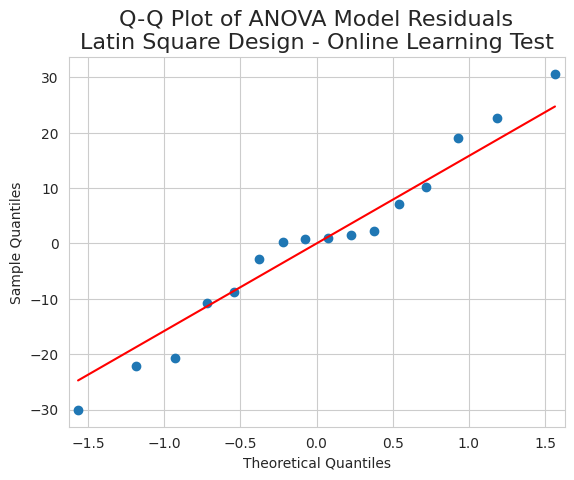

Shapiro-Wilk Test Statistic: 0.9727, p-value: 0.8797
✅ Residuals appear to be normally distributed (fail to reject H0).


In [15]:
## Fit ANOVA Model ##

oleplat_mod = ols("Engagement~Platform+Section+Day",data=ole_data).fit()

## Extract Residuals ##

platform_residuals = oleplat_mod.resid

## Plot QQ-Plot with seaborn ##

sm.qqplot(platform_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals\nLatin Square Design - Online Learning Test",
          loc='center',
          fontsize=16)
plt.show()

## S-W Test ##

sw = stats.shapiro(platform_residuals)

## Extract Test Stat & p-value ##
sw_stat = sw.statistic
sw_pval = sw.pvalue
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}, p-value: {sw_pval:.4f}")
if sw_pval > 0.05:
    print("✅ Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("❌ Residuals do not appear to be normally distributed (reject H0).")

  * In the QQ-Plot, the points mostly follow the center diagonal line, with slight deviation. The p-value of the S-W test is 0.8797, which is greater than 0.05, concluding the data is normally distributed.


  Question 8. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

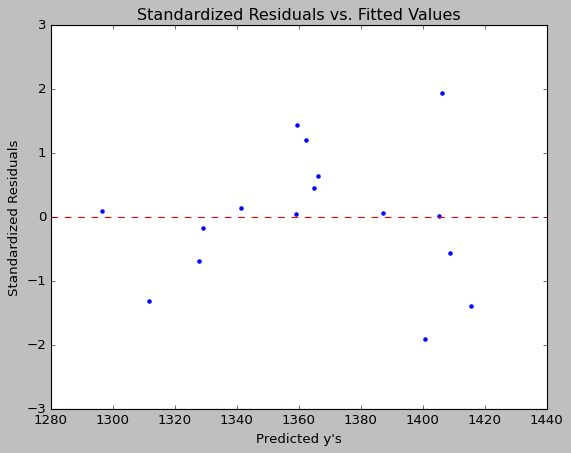

F-statistic: 1.049626278013382
F p-value: 0.49513363026521345
✅ Residuals appear to have constant variance (fail to reject H0).


In [18]:
## Assessing Constant Variance ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

ole_standardized_residuals = oleplat_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

ole_fitted_values = oleplat_mod.fittedvalues

## Create the plot ##

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ole_fitted_values, y=ole_standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

ole_bp_test = het_breuschpagan(oleplat_mod.resid,oleplat_mod.model.exog)

## Extract F-statistic ##

f_statistic2 = ole_bp_test[2]

## Extract its P-Value ##

f_p_value2 = ole_bp_test[3]

print(f"F-statistic: {f_statistic2}")
print(f"F p-value: {f_p_value2}")
if f_p_value2 > 0.05:
    print("✅ Residuals appear to have constant variance (fail to reject H0).")
else:
    print("❌ Residuals do not appear to have constant variance (reject H0).")

  * The points are randomly scattered by 0. The B-P test p-value of 0.495, greater than the threshold of 0.05, indicates the data has constant variance.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



In [19]:
## Print ANOVA Table ##
ole_tab = sm.stats.anova_lm(oleplat_mod,typ=3)
## Add Significance Column ##
ole_tab['Sig'] = np.where(ole_tab['PR(>F)']<0.05,'Yes','No')
## Print only the main effect and blocking factor rows ##
print(ole_tab.loc[['Platform','Section','Day']])


                sum_sq   df         F    PR(>F)  Sig
Platform  15221.225819  3.0  7.607701  0.018122  Yes
Section    2396.427869  3.0  1.197756  0.387569   No
Day        2774.676069  3.0  1.386807  0.334557   No


  * Examining our main effect Platform, the p-value associated with this factor is 0.018. This indicates that the data more strongly support the alternative hypothesis, indicating that at least two of our platforms may have meaningfully differing mean engagement count.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B -69.1275 0.0186 -127.1688 -11.0862   True
     A      C  -76.205 0.0099 -134.2463 -18.1637   True
     A      D  -29.825 0.4534  -87.8663  28.2163  False
     B      C  -7.0775  0.983  -65.1188  50.9638  False
     B      D  39.3025 0.2375  -18.7388  97.3438  False
     C      D    46.38 0.1359  -11.6613 104.4213  False
-------------------------------------------------------


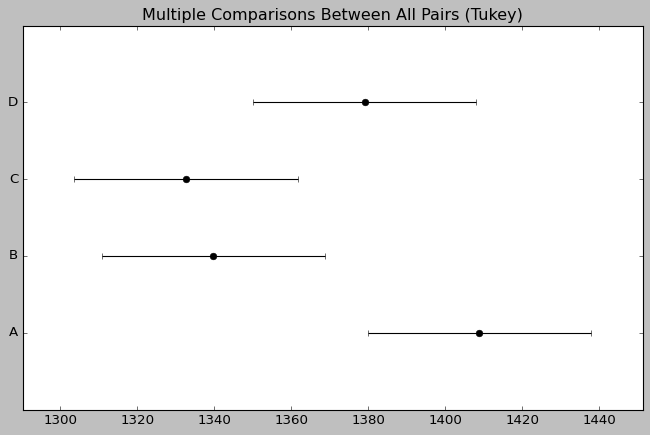

In [20]:
## Tukey's HSD Function Already Imported Above ##

ole_tukey_result = pairwise_tukeyhsd(endog=ole_data['Engagement'], groups=ole_data['Platform'],
                                 alpha=0.05)

## Print Tukey Visual Summary ##

ole_tukey_result.plot_simultaneous()

print(ole_tukey_result)

  * The results of the Tukey test illustrates the mean engagement count for online platform A is statistically different from platform B and C, controlling for time of day and day of the week at the 0.05 level.

**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

  * This experiment controlled for the time of day and day of the week that students logged into the online learning platform, to determine the most used platform. The post-hoc analysis determined that
 platform A is statistically different from platform B and C, while the other groups did not differ from each other. Contextually, the online learning platform A yielded the higher engagement out of all four platforms.
  * A potential limitation would be not knowing how long students were logged in. The engagement clicks don't determine if the learning platform is effective. For a furture experiment, one could look into how long students are using the platform when logged in.